In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2023-01-01
Revised on 2026-04-04

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — toolbox vignette, R to Python (_r2p)
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Normal Distribution, Q-Q Plots, Shapiro-Wilk Tests — Toolbox Vignette (_r2p)
=============================================================================

Purpose:
    Demonstrates Normal distribution properties, Q-Q plots, and
    Shapiro-Wilk normality tests.

    Three sections:

      Section 1 — Build a Normal sample:
        Generate N(0,1) sample of size S=100. Compute mean and sd.
        Repeat N=30 times, store means. Verify SD of means.
        Demonstrates: sample mean variability, standard error of the mean.

      Section 2 — Q-Q plots + boxplots (4 trials x 2 panels):
        4 independent trials of 30 means of N(0,1) samples.
        Each trial: Q-Q plot with Shapiro-Wilk p-value + boxplot.
        Demonstrates: normality of sample means (CLT), Shapiro-Wilk H0.

      Section 3 — Effect of sample size on normality (3 x 4 panel):
        Sample sizes: 10, 100, 1000. 4 trials each.
        Q-Q plots with Shapiro-Wilk p-values.
        Demonstrates: Central Limit Theorem — larger N → cleaner normality.

    Key concept — Shapiro-Wilk test:
      H0: sample comes from a Normal distribution
      HA: sample does NOT come from a Normal distribution
      p-value > 0.05 → keep H0 (consistent with normality)
      p-value < 0.05 → reject H0 (evidence against normality)

    R equivalent: normal_dist_q-q_plots_shapiro-wilk_vignette.Rmd
    R libraries:  base R only (qqnorm, qqline, shapiro.test, boxplot)
    Python libs:  numpy, matplotlib, scipy.stats, statsmodels

    Suffix _r2p: This notebook was converted from R to Python.

Revision History:
    2023-01-01  Original R development (Harvard Elements of Statistical Learning)
                - R script: normal_dist_q-q_plots_shapiro-wilk_vignette.Rmd

    2026-04-04  Converted to Python / Jupyter Notebook (_r2p)
                - rnorm(S) → np.random.default_rng().normal()
                - shapiro.test() → scipy.stats.shapiro()
                - qqnorm() + qqline() → statsmodels.api.qqplot()
                - par(mfrow=c(4,2)) → plt.subplots(4, 2)
                - par(mfrow=c(3,4)) → plt.subplots(3, 4)
                - Harvard color palette preserved as hex constants
"""

'\nCreated on 2023-01-01\nRevised on 2026-04-04\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — toolbox vignette, R to Python (_r2p)\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nNormal Distribution, Q-Q Plots, Shapiro-Wilk Tests — Toolbox Vignette (_r2p)\n=============================================================================\n\nPurpose:\n    Demonstrates Normal distribution properties, Q-Q plots, and\n    Shapiro-Wilk normality tests.\n\n    Three sections:\n\n      Section 1 — Build a Normal sample:\n        Generate N(0,1) sample of size S=100. Compute mean and sd.\n        Repeat N=30 times, store means. Verify SD of means.\n        Demonstrates: sample mean variability, standard error of the mean.\n\n      Section 2 — Q-Q plots + boxplots (4 trials x 2 panels):\n        4 independent trials of 30 means of N(0,1) samples.\n        Each trial: Q-Q plot with Shapir

# Normal Distribution, Q-Q Plots, Shapiro-Wilk Tests — Toolbox Vignette

## Overview

Demonstrates Normal distribution properties, Q-Q plots, and Shapiro-Wilk normality tests.

| Section | Topic | Key concept |
|---------|-------|-------------|
| 1 | Build a Normal sample | Sample mean, SD, standard error |
| 2 | Q-Q + boxplot (4 trials) | Normality of sample means, Shapiro-Wilk H₀ |
| 3 | Sample size effect (3×4) | Central Limit Theorem |

**Shapiro-Wilk test:**
- H₀: sample comes from a Normal distribution
- p-value > 0.05 → keep H₀ (consistent with normality)
- p-value < 0.05 → reject H₀ (evidence against normality)

**R equivalent:** `normal_dist_q-q_plots_shapiro-wilk_vignette.Rmd`

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

import matplotlib as mpl
# For subscript notation:
mpl.rcParams['font.family'] = 'DejaVu Sans'

import seaborn as sns
sns.set_theme(style='whitegrid')

# Harvard color palette
CRIMSON   = '#A51C30'
ROYALBLUE = '#002366'
SLATE     = '#8996A0'
IVY       = '#52854C'
SAFFRON   = '#D16103'

print('Imports complete.')

Imports complete.


---

# Section 1: Build a Normally Distributed Dataset

## Generate a Sample of Size S=100

Mirrors R:
```r
S <- 100
y <- rnorm(S)
mu <- mean(y)
sigma <- sd(y)
```

`rnorm(S)` generates S random numbers from N(0,1).
The resulting mean and SD will be close to 0 and 1 — but not exactly,
due to the randomness of sampling.

In [3]:
# Sample size — mirrors R: S <- 100
S   = 100
rng = np.random.default_rng(seed=42)

# Generate sample — mirrors R: y <- rnorm(S)
y = rng.normal(0, 1, S)

# Compute mean and sd — mirrors R: mu <- mean(y); sigma <- sd(y)
mu    = np.mean(y)
sigma = np.std(y, ddof=1)   # ddof=1 mirrors R's sd() which uses N-1

# Display — mirrors R: paste(' Mean of y = ', round(mu, digits=2))
print(f' Mean of y = {mu:.2f}')
print(f' Standard deviation of y = {sigma:.2f}')
print()
print('Note: rnorm(100) generates N(0,1) random numbers.')
print('Theoretical mean=0, sd=1. Empirical values are close but not exact due to randomness.')

 Mean of y = -0.05
 Standard deviation of y = 0.78

Note: rnorm(100) generates N(0,1) random numbers.
Theoretical mean=0, sd=1. Empirical values are close but not exact due to randomness.


## Repeat N=30 Times — Store the Means

Mirrors R:
```r
N <- 30
MEAN <- numeric(N)
for (i in 1:N) { MEAN[i] <- mean(rnorm(S)) }
SIGMA <- sd(MEAN)
```

Each trial: draw 100 N(0,1) values, compute their mean, store it.
After 30 trials: compute the SD of those 30 means.

The SD of sample means = **standard error of the mean** ≈ 1/√S = 1/√100 = 0.1

In [4]:
# N trials — mirrors R: N <- 30; MEAN <- numeric(N)
N    = 30
MEAN = np.array([rng.normal(0, 1, S).mean() for _ in range(N)])

SIGMA = np.std(MEAN, ddof=1)   # mirrors R: sd(MEAN)

print(f'The standard deviation of MEAN is {SIGMA:.2f}')
print(f'Expected (theoretical SE): 1/sqrt({S}) = {1/np.sqrt(S):.4f}')
print()
print('Takeaway: SIGMA (SD of means) is much smaller than sigma (SD of raw values).')
print('The means cluster tightly around 0 — this is the standard error of the mean.')

The standard deviation of MEAN is 0.11
Expected (theoretical SE): 1/sqrt(100) = 0.1000

Takeaway: SIGMA (SD of means) is much smaller than sigma (SD of raw values).
The means cluster tightly around 0 — this is the standard error of the mean.


---

# Section 2: Q-Q Plots and Boxplots — 4 Trials

Mirrors R:
```r
par(mfrow=c(4,2))
for (i in 1:4) {
  for (j in 1:N) { MEAN[j] <- mean(rnorm(S)) }
  SHAPIRO <- shapiro.test(MEAN)
  qqnorm(MEAN, col='blue', main=paste('Q-Q Plot. Normality p-value=', ...))
  qqline(MEAN, col='red')
  boxplot(MEAN, col='lightblue', ...)
}
```

4 independent trials of 30 means of N(0,1) samples.
Each trial: Q-Q plot with Shapiro-Wilk p-value + boxplot.

**Shapiro-Wilk H₀:** the sample comes from a Normal distribution.
We expect all p-values > 0.05 — sample means are normally distributed.

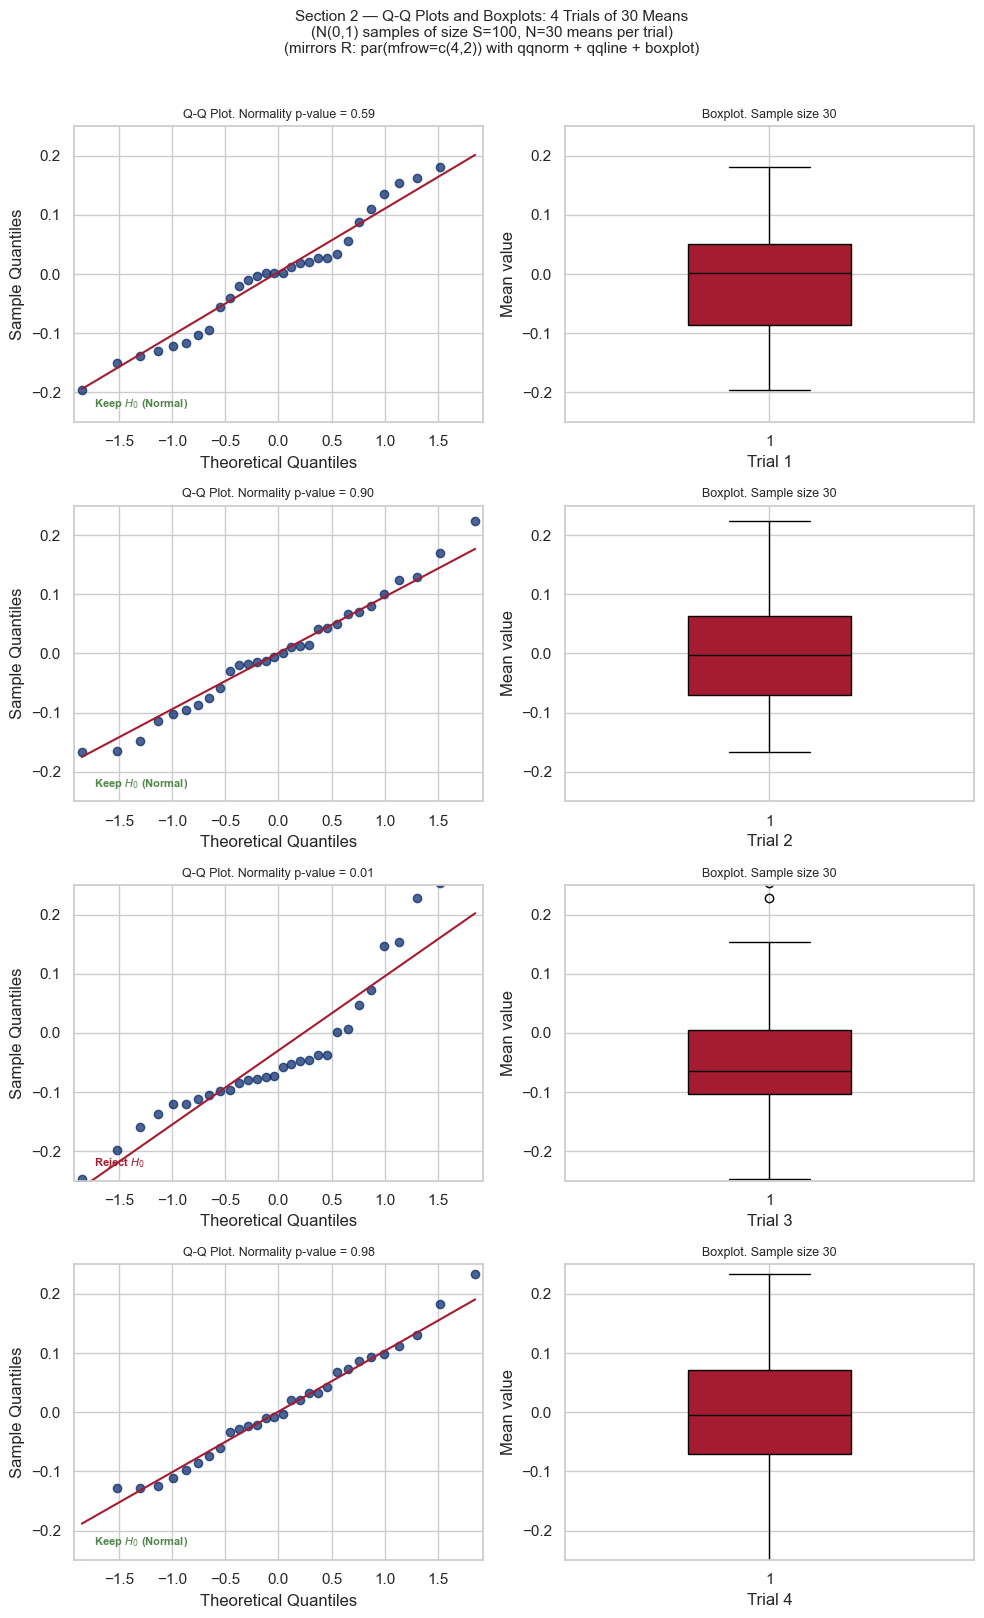

In [5]:
# 4 trials x 2 panels (Q-Q + boxplot) — mirrors R: par(mfrow=c(4,2))
fig, axes = plt.subplots(4, 2, figsize=(10, 16))

for i in range(4):
    # Regenerate MEAN for each trial — mirrors R inner for loop
    MEAN_trial = np.array([rng.normal(0, 1, S).mean() for _ in range(N)])

    # Shapiro-Wilk test — mirrors R: shapiro.test(MEAN)
    shapiro_stat, shapiro_p = stats.shapiro(MEAN_trial)

    # --- Left panel: Q-Q plot ---
    # mirrors R: qqnorm(MEAN, col='blue') + qqline(MEAN, col='red')
    ax_qq = axes[i, 0]
    sm.qqplot(MEAN_trial, line='s', ax=ax_qq,
              marker='o', markerfacecolor=ROYALBLUE,
              markeredgecolor=ROYALBLUE, alpha=0.7)
    # Recolor the reference line to red — mirrors R qqline col='red'
    for line in ax_qq.get_lines():
        line.set_color(CRIMSON)
        line.set_linewidth(1.5)
    ax_qq.set_ylim(-0.25, 0.25)   # mirrors R: ylim=c(-0.2, 0.2)
    ax_qq.set_title(f'Q-Q Plot. Normality p-value = {shapiro_p:.2f}',
                    fontsize=9)
    ax_qq.set_xlabel('Theoretical Quantiles')
    ax_qq.set_ylabel('Sample Quantiles')

    # Annotate H0 decision
    decision = r'Keep $H_0$ (Normal)' if shapiro_p > 0.05 else r'Reject $H_0$'
    color    = IVY if shapiro_p > 0.05 else CRIMSON
    ax_qq.text(0.05, 0.05, decision, transform=ax_qq.transAxes,
               color=color, fontsize=8, fontweight='bold')

    # --- Right panel: Boxplot ---
    # mirrors R: boxplot(MEAN, col='lightblue', main=paste('Boxplot. Sample size ', N))
    ax_bp = axes[i, 1]
    bp = ax_bp.boxplot(MEAN_trial, patch_artist=True,
                        vert=True, widths=0.4)
    bp['boxes'][0].set_facecolor(CRIMSON)   # mirrors R: col='lightblue'
    for element in ['whiskers', 'caps', 'medians', 'fliers']:
        for patch in bp[element]:
            patch.set_color('black')
    ax_bp.set_title(f'Boxplot. Sample size {N}', fontsize=9)
    ax_bp.set_xlabel(f'Trial {i+1}')   # mirrors R: xlab=paste('Trial ', i)
    ax_bp.set_ylabel('Mean value')
    ax_bp.set_ylim(-0.25, 0.25)

fig.suptitle('Section 2 — Q-Q Plots and Boxplots: 4 Trials of 30 Means\n'
             f'(N(0,1) samples of size S={S}, N={N} means per trial)\n'
             '(mirrors R: par(mfrow=c(4,2)) with qqnorm + qqline + boxplot)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

**Takeaways** (from original R vignette):

- Each panel shows a **Q-Q plot** and **boxplot** for one trial of 30 sample means.
- The Q-Q plot diagonal line (`qqline`) helps visualize normality — points close to the line indicate normality.
- **Shapiro-Wilk p-values** (shown in each Q-Q title) are all > 0.05, so we **keep H₀** — the sample means come from a Normal distribution.
- Some tails appear in the Q-Q plots — this is expected with only N=30 means. Not all points fall exactly on the line due to random variation.
- The **boxplots** are narrow and consistent, with quartiles near \[−0.1, +0.1\] — reflecting the small standard error of the mean (≈ 1/√100 = 0.1).
- **Conclusion:** Sample means of N(0,1) data are themselves Normally distributed — the Central Limit Theorem at work.

---

# Section 3: Effect of Sample Size on Normality — 3×4 Panel

Mirrors R:
```r
par(mfrow=c(3,4))
S <- c(10, 100, 1000)
for (i in 1:3) {
  for (j in 1:4) {
    SAMPLE <- rnorm(S[i])
    SHAPIRO <- shapiro.test(SAMPLE)
    qqnorm(SAMPLE, col='blue', main=paste('Q-Q Plot. Normality p-value=', ...))
    qqline(SAMPLE, col='red')
  }
}
```

3 sample sizes × 4 trials each = 12 Q-Q plots.
**Demonstrates the Central Limit Theorem:** as N increases,
the sample distribution becomes increasingly Normal.

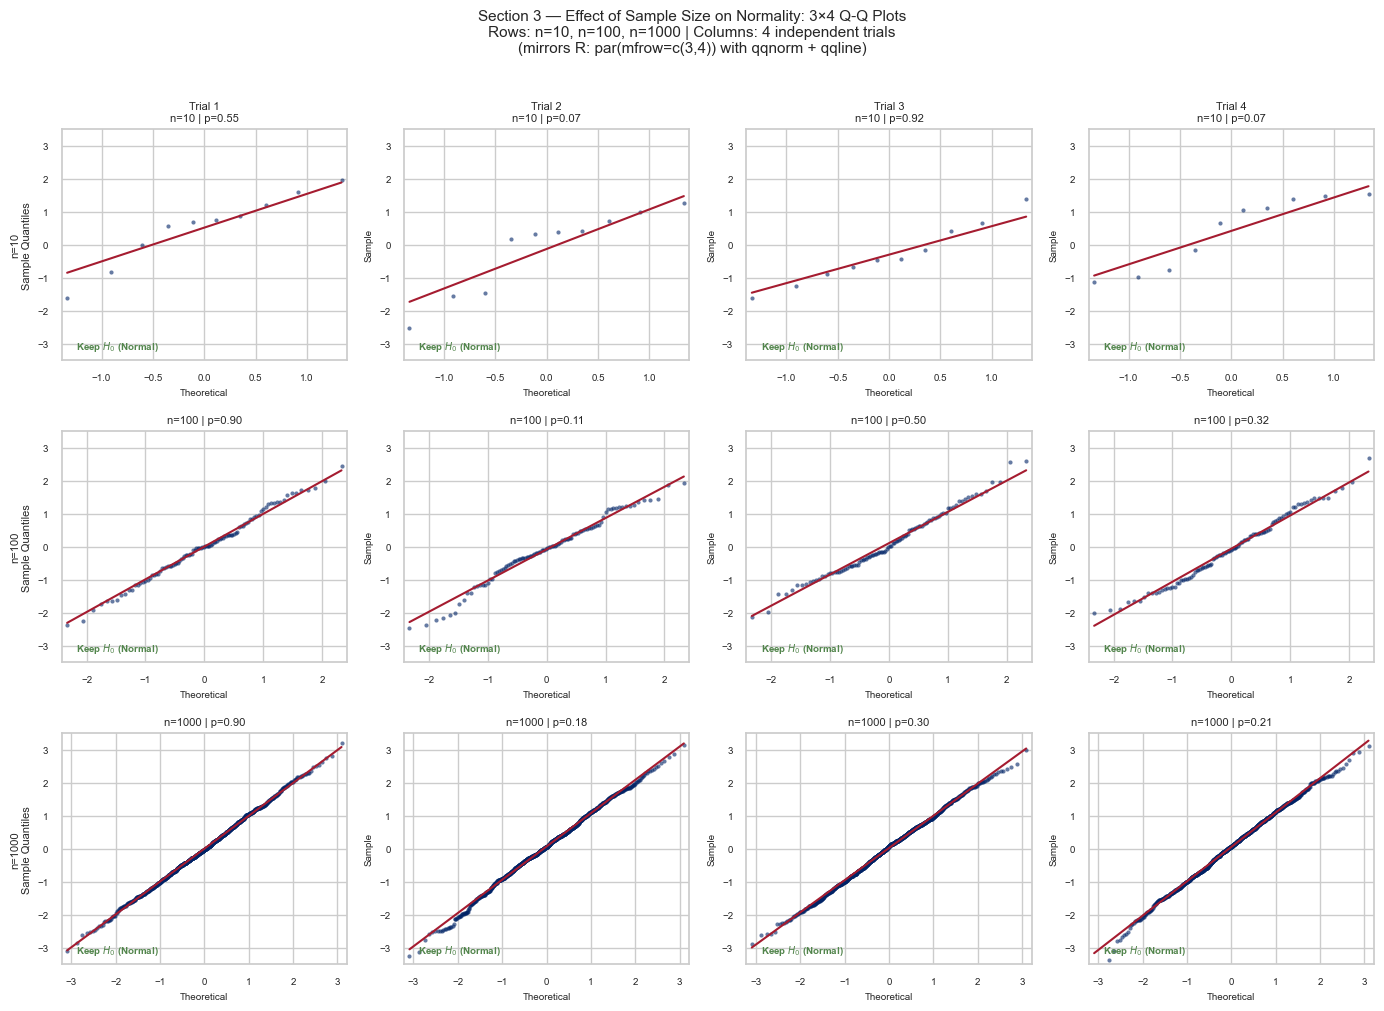

In [6]:
# 3 sample sizes x 4 trials — mirrors R: par(mfrow=c(3,4))
S_values = [10, 100, 1000]   # mirrors R: S <- c(10, 100, 1000)
n_trials = 4

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for i, s_val in enumerate(S_values):
    for j in range(n_trials):
        # Random sample of size S[i] — mirrors R: SAMPLE <- rnorm(S[i])
        SAMPLE = rng.normal(0, 1, s_val)

        # Shapiro-Wilk — mirrors R: shapiro.test(SAMPLE)
        shapiro_stat, shapiro_p = stats.shapiro(SAMPLE)

        ax = axes[i, j]

        # Q-Q plot — mirrors R: qqnorm(SAMPLE, col='blue') + qqline(col='red')
        sm.qqplot(SAMPLE, line='s', ax=ax,
                  marker='o', markerfacecolor=ROYALBLUE,
                  markeredgecolor='none', markersize=3, alpha=0.6)
        for line in ax.get_lines():
            line.set_color(CRIMSON)
            line.set_linewidth(1.5)
        ax.set_ylim(-3.5, 3.5)   # mirrors R: ylim=c(-2,2) — extended for N=1000
        ax.set_title(f'n={s_val} | p={shapiro_p:.2f}', fontsize=8)
        ax.set_xlabel('Theoretical', fontsize=7)
        ax.set_ylabel('Sample', fontsize=7)
        ax.tick_params(labelsize=7)

        # Annotate H0 decision
        decision = r'Keep $H_0$ (Normal)' if shapiro_p > 0.05 else r'Reject $H_0$'
        color    = IVY if shapiro_p > 0.05 else CRIMSON
        ax.text(0.05, 0.05, decision, transform=ax.transAxes,
                color=color, fontsize=7, fontweight='bold')

    # Row label
    axes[i, 0].set_ylabel(f'n={s_val}\nSample Quantiles', fontsize=8)

# Column headers
for j in range(n_trials):
    axes[0, j].set_title(f'Trial {j+1}\nn=10 | p={axes[0,j].get_title().split("p=")[1]}',
                          fontsize=8)

fig.suptitle('Section 3 — Effect of Sample Size on Normality: 3×4 Q-Q Plots\n'
             'Rows: n=10, n=100, n=1000 | Columns: 4 independent trials\n'
             '(mirrors R: par(mfrow=c(3,4)) with qqnorm + qqline)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

**Takeaways** (from original R vignette):

- All Shapiro-Wilk tests keep H₀ (p > 0.05) — every sample came from a Normal distribution by design.
  But the **degree of evidence** increases dramatically with sample size.

- **n=10 (top row):** Irregular Q-Q plots. Points frequently deviate from the line.
  Slopes vary noticeably between trials. Small samples show high variability.

- **n=100 (middle row):** Improvement. Tails may still appear at either end,
  but the central portion aligns well. More consistent between trials.

- **n=1000 (bottom row):** Near-perfect alignment with the Q-Q line in all 4 trials.
  The **Central Limit Theorem** is clearly visible — large samples produce
  near-Normal distributions with high confidence.

- **Conclusion:** Even though all samples are drawn from N(0,1), the *apparent*
  normality in a Q-Q plot depends heavily on sample size. With n=10, any single
  sample may look non-normal by chance. With n=1000, non-normality would be
  immediately obvious.

---

# Section 4: Shapiro-Wilk p-value Distribution Across Samples

Not in the original R script — added as a Python extension.
Run 200 Shapiro-Wilk tests for each sample size and plot the
distribution of p-values. Shows how p-value behavior changes with N.

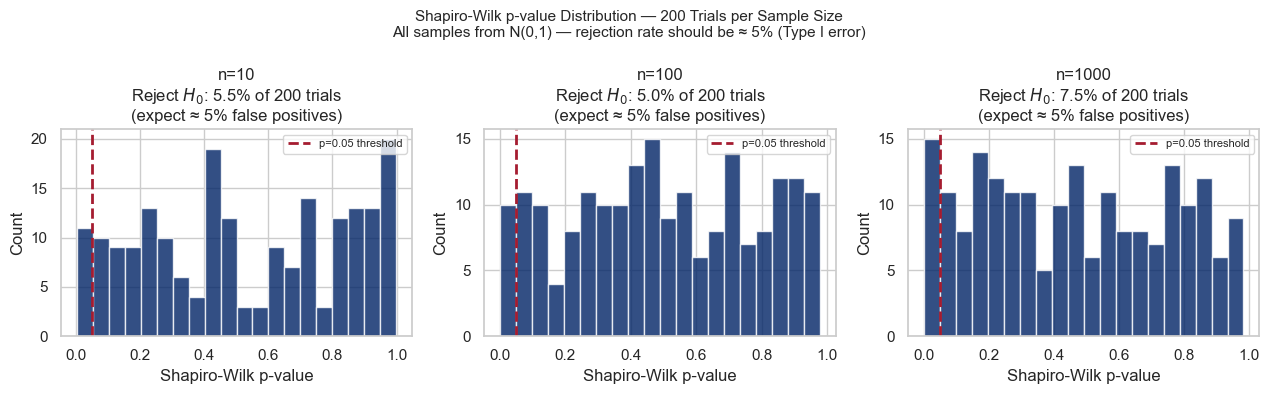

In [7]:
# Distribution of Shapiro-Wilk p-values across many trials
n_reps   = 200
S_values = [10, 100, 1000]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

for ax, s_val in zip(axes, S_values):
    p_values = [stats.shapiro(rng.normal(0, 1, s_val))[1]
                for _ in range(n_reps)]
    reject_pct = np.mean(np.array(p_values) < 0.05) * 100

    ax.hist(p_values, bins=20, color=ROYALBLUE, alpha=0.8,
            edgecolor='white')
    ax.axvline(0.05, color=CRIMSON, linestyle='--', linewidth=2,
               label='p=0.05 threshold')
    ax.set_xlabel('Shapiro-Wilk p-value')
    ax.set_ylabel('Count')
    ax.set_title(f'n={s_val}\n'
                 f'Reject $H_0$: {reject_pct:.1f}% of {n_reps} trials\n'
                 f'(expect ≈ 5% false positives)')
    ax.legend(fontsize=8)

fig.suptitle('Shapiro-Wilk p-value Distribution — 200 Trials per Sample Size\n'
             'All samples from N(0,1) — rejection rate should be ≈ 5% (Type I error)',
             fontsize=11)
plt.tight_layout()
plt.show()

---

# Summary

## Key Takeaways

1. **Standard error of the mean:** The SD of sample means ≈ σ/√n = 1/√100 = 0.1.
   Individual observations vary widely; means cluster tightly — a fundamental
   property of sampling distributions.

2. **Shapiro-Wilk test:** Tests H₀ that the sample is Normal.
   p > 0.05 → keep H₀. By design, all samples here come from N(0,1),
   so we expect to keep H₀ — and we do, in all trials.

3. **Central Limit Theorem:** n=10 Q-Q plots are irregular; n=1000 are
   near-perfect. The same underlying N(0,1) distribution looks increasingly
   Normal in the Q-Q plot as sample size grows.

4. **Type I error rate:** Even from a Normal distribution, ~5% of Shapiro-Wilk
   tests will reject H₀ by chance at the 0.05 threshold — the false positive
   rate. Section 4 demonstrates this empirically.

## R → Python Mapping

| R | Python |
|---|--------|
| `rnorm(S)` | `rng.normal(0, 1, S)` |
| `mean(y)` | `np.mean(y)` |
| `sd(y)` | `np.std(y, ddof=1)` |
| `numeric(N)` | `np.zeros(N)` or list comprehension |
| `shapiro.test(x)` | `scipy.stats.shapiro(x)` returns `(statistic, p_value)` |
| `shapiro.test(x)$p.value` | `stats.shapiro(x)[1]` |
| `qqnorm(x, col='blue')` | `sm.qqplot(x, line='s', ax=ax)` |
| `qqline(x, col='red')` | Recolor lines from `sm.qqplot` |
| `boxplot(x, col='lightblue')` | `ax.boxplot(x, patch_artist=True)` |
| `par(mfrow=c(4,2))` | `plt.subplots(4, 2)` |
| `par(mfrow=c(3,4))` | `plt.subplots(3, 4)` |
| `round(x, digits=2)` | `round(x, 2)` or `f'{x:.2f}'` |
| `paste(...)` | `f'...'` f-strings |

## References

1. Harvard Elements of Statistical Learning (2021),
   Dr. Andrey Sivachenko and Dr. Victor A. Farutin.
2. Gareth James, et al. *An Introduction to Statistical Learning
   with Applications in R*. Springer. ISBN 978-1-4614-7137-0.
3. James, G., Witten, D., Hastie, T., Tibshirani, R., Taylor, J.
   *An Introduction to Statistical Learning with Applications in Python*.
   Springer, 2023. https://www.statlearning.com